<a href="https://colab.research.google.com/github/elemnurguner/data-ai-projects/blob/main/face_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade numpy==1.23.5
!pip install opencv-python-headless==4.8.0.76
!pip install tensorflow==2.12.0
!pip install deepface==0.0.79
!pip install mtcnn==0.1.1

In [ ]:
!pip install scipy


=== GELİŞMİŞ YÜZ TANIMA SİSTEMİ ===

1. ADIM: Tanınacak kişileri ekleyin
Kişi adı (çıkmak için 'q'): elen 
elen  için resim yükleyin:


Saving Elon_Musk_Royal_Society.jpg to Elon_Musk_Royal_Society (10).jpg
1/1 [==============================] - 0s 20ms/step
elen  başarıyla eklendi
Kişi adı (çıkmak için 'q'): 
 için resim yükleyin:


Saving 6e277191-d061-407a-8001-e6a64686a558_size1500x1500_quality100_cropCenter.jpg to 6e277191-d061-407a-8001-e6a64686a558_size1500x1500_quality100_cropCenter.jpg
: Yüz bulunamadı
Kişi adı (çıkmak için 'q'): q

2. ADIM: Tanınacak resmi yükleyin
Tanıma yapılacak resmi yükleyin:


Saving MESSI.jpg to MESSI.jpg

3. ADIM: Sonuçlar
1/1 [==============================] - 0s 19ms/step


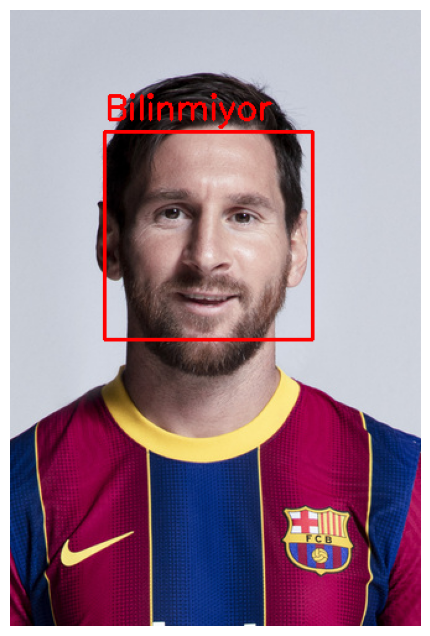

In [11]:
import cv2
import numpy as np
from deepface import DeepFace
import matplotlib.pyplot as plt
from google.colab import files
import os
from scipy.spatial.distance import cosine

class ImprovedFaceRecognition:
    def __init__(self):
        self.known_embeddings = {}
        self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    def load_image(self, file_path):
        """Resmi yükleyip RGB formatına çevirir"""
        try:
            img = cv2.imread(file_path)
            if img is None:
                raise ValueError("Resim yüklenemedi")
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except Exception as e:
            print(f"Resim yükleme hatası: {str(e)}")
            return None

    def add_person(self, name, img_path):
        """Kişiyi veritabanına ekler"""
        img = self.load_image(img_path)
        if img is None:
            return False

        try:
            # Yüz tespiti
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            faces = self.face_cascade.detectMultiScale(gray, 1.1, 4)

            if len(faces) == 0:
                print(f"{name}: Yüz bulunamadı")
                return False

            x, y, w, h = faces[0]
            face_img = img[y:y+h, x:x+w]

            # Embedding oluşturma
            embedding = DeepFace.represent(
                face_img,
                model_name='Facenet',
                enforce_detection=False,
                detector_backend='mtcnn'
            )
            self.known_embeddings[name] = embedding[0]['embedding']
            print(f"{name} başarıyla eklendi")
            return True

        except Exception as e:
            print(f"{name} eklenirken hata: {str(e)}")
            return False

    def recognize_faces(self, test_img_path):
        """Resimdeki yüzleri tanır ve etiketler"""
        img = self.load_image(test_img_path)
        if img is None:
            return None

        try:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            faces = self.face_cascade.detectMultiScale(gray, 1.1, 4)

            if len(faces) == 0:
                print("Yüz bulunamadı")
                return img

            for (x, y, w, h) in faces:
                face_img = img[y:y+h, x:x+w]

                # Test yüz embeddingi
                test_embedding_result = DeepFace.represent(
                    face_img,
                    model_name='Facenet',
                    enforce_detection=False,
                    detector_backend='mtcnn'
                )
                test_embedding = test_embedding_result[0]['embedding']

                # Kayıtlı kişilerle karşılaştır
                best_match_name = "Bilinmiyor"
                best_distance = 1.0
                threshold = 0.65

                for name, known_embedding in self.known_embeddings.items():
                    distance = cosine(test_embedding, known_embedding)
                    if distance < best_distance:
                        best_distance = distance
                        best_match_name = name

                if best_distance < threshold:
                    label = f"{best_match_name} ({best_distance:.2f})"
                    color = (0, 255, 0)
                else:
                    label = "Bilinmiyor"
                    color = (255, 0, 0)

                cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)
                cv2.putText(img, label, (x, y-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

            return img

        except Exception as e:
            print(f"İşlem hatası: {str(e)}")
            return None

def upload_image(prompt):
    """Resim yükleme fonksiyonu"""
    print(prompt)
    uploaded = files.upload()
    if not uploaded:
        print("Resim yüklenmedi!")
        return None
    return list(uploaded.keys())[0]

# Ana program
def run_face_recognition():
    print("=== GELİŞMİŞ YÜZ TANIMA SİSTEMİ ===")
    fr = ImprovedFaceRecognition()

    # 1. Kişileri ekleme
    print("\n1. ADIM: Tanınacak kişileri ekleyin")
    while True:
        name = input("Kişi adı (çıkmak için 'q'): ")
        if name.lower() == 'q':
            break
        img_path = upload_image(f"{name} için resim yükleyin:")
        if img_path:
            fr.add_person(name, img_path)

    # 2. Tanıma yapılacak resim
    print("\n2. ADIM: Tanınacak resmi yükleyin")
    test_img = upload_image("Tanıma yapılacak resmi yükleyin:")
    if not test_img:
        return

    # 3. Sonuçları göster
    print("\n3. ADIM: Sonuçlar")
    result = fr.recognize_faces(test_img)
    if result is not None:
        plt.figure(figsize=(12, 8))
        plt.imshow(result)
        plt.axis('off')
        plt.show()

# Programı çalıştır
run_face_recognition()


# 📸 Gelişmiş Yüz Tanıma Sistemi

Bu proje, DeepFace kütüphanesi ve OpenCV kullanarak resimlerdeki yüzleri tanıyan ve etiketleyen basit bir Python uygulamasıdır. Kullanıcılar kendi veri tabanlarını oluşturabilir ve yükledikleri test görsellerinde kişileri tanıyabilirler.

---

## 🚀 Özellikler

- 📥 Kullanıcıdan kişi resimleri yükleme
- 🎯 DeepFace ile yüz embedding çıkarma
- 🗂 Hafızada kişiye ait embeddingleri saklama (kişisel mini veritabanı)
- 🧭 Yeni bir fotoğraftaki yüzleri tanıma ve karşılaştırma
- ✅ Cosine distance kullanarak en yakın kişiyi bulma
- 🖼 Sonuçları resim üzerinde etiketleme ve gösterme

---

## 🛠 Kullanılan Kütüphaneler

- Python 3.x
- OpenCV
- DeepFace
- NumPy
- SciPy
- Matplotlib
- Google Colab (isteğe bağlı dosya yüklemek için)

---

## ⚙️ Çalışma Mantığı

1️⃣ **Kişi Ekleme:**  
Kullanıcıdan bir kişi adı ve o kişinin yüz fotoğrafı alınır.  
DeepFace kullanılarak yüz embeddingi çıkarılır ve bellekte bir sözlükte saklanır.

2️⃣ **Tanıma:**  
Kullanıcıdan test resmi alınır.  
Resimdeki yüzler tespit edilir ve embeddingleri çıkarılır.  
Kayıtlı embeddinglerle cosine mesafesi karşılaştırılır.  
Eşik değeri altında en yakın eşleşme etiketlenir.

3️⃣ **Sonuç:**  
Resim üzerinde yüzün etrafına kutu çizilir ve ismi yazılır.  
Matplotlib ile görselleştirilir.

---


## 📦 Kurulum

Google Colab ortamında çalışmak için:

```python
!pip install deepface opencv-python matplotlib scipy
